# Macroeconomia avançada 1 - Atividade 4 - Modelo VEC

**Aluno**: José Kawan dos Santos Santana

## Questão 1 

De posse da base de dados **data_vec_alunos.xls**, disponível na pasta da turma, estime um modelo VEC e calcule as elasticidades de curto e longo prazos da demanda de gasolina.

- Aplique a metodologia Engle-Granger como visto em sala de aula e compare seus resultados 
com Alves and Bueno (2003)
- Refaça o exercício usando o procedimento de Johansen..

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

data_vec_alunos = pd.read_excel('data_vec_alunos.xlsx')
data_vec_alunos.head()

,Ano,PIB_cap,Pgasolina,Petanol,Cgasolina
0,1994,15327.399780,86.395930,69.781328,11806.0
1,1995,15752.265379,146.423789,118.153437,14119.0
2,1996,15839.248228,190.246852,156.488726,16524.0
3,1997,16068.310820,248.721799,213.015397,18071.0
4,1998,15797.149043,299.157591,251.511835,19003.0


In [2]:
data_vec_alunos.isna().sum()

Ano          0
PIB_cap      0
Pgasolina    0
Petanol      0
Cgasolina    0
dtype: int64

In [3]:
data_vec_alunos.dtypes

Ano            int64
PIB_cap      float64
Pgasolina    float64
Petanol      float64
Cgasolina    float64
dtype: object

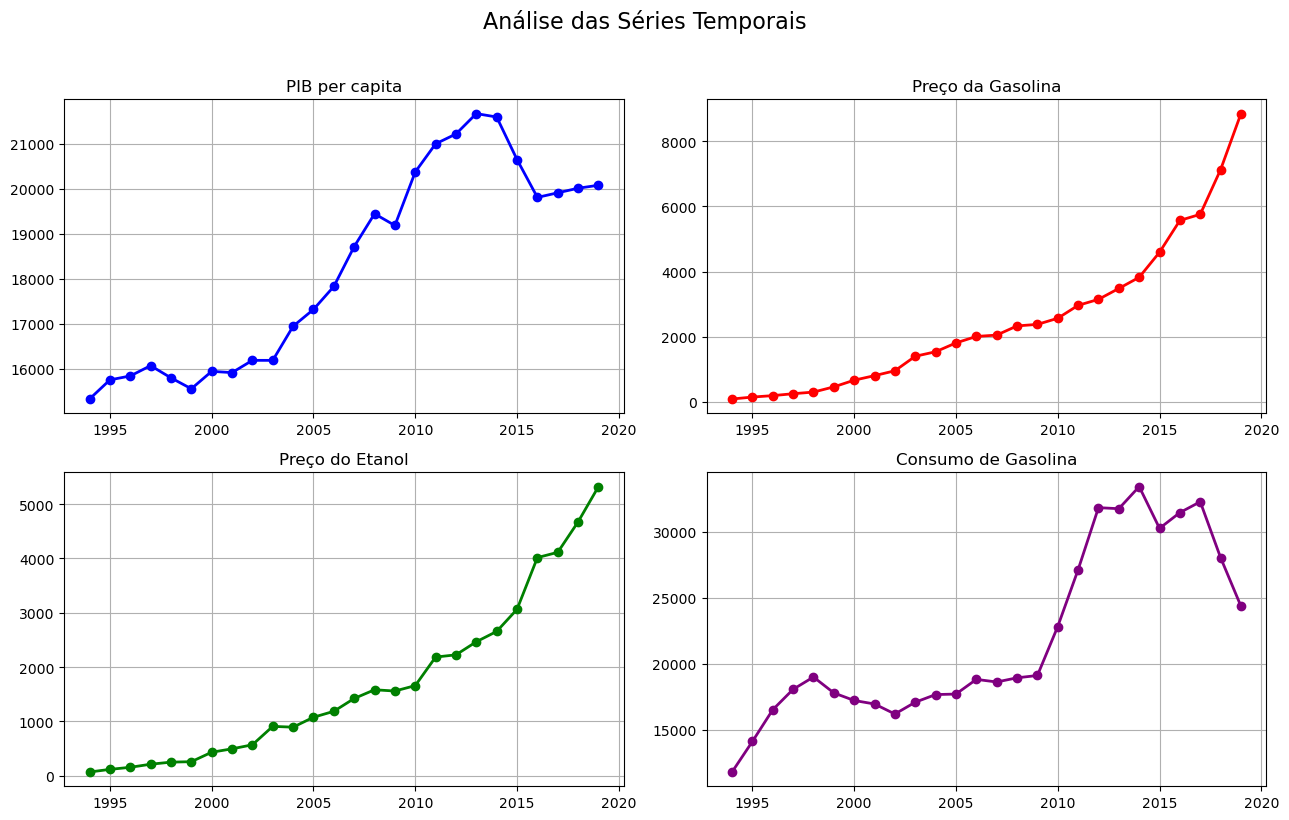

In [4]:
X = data_vec_alunos['Ano']
Y = data_vec_alunos['PIB_cap']
Z = data_vec_alunos['Pgasolina']
H = data_vec_alunos['Petanol']
W = data_vec_alunos['Cgasolina']

# Cria a figura e os subplots (2 linhas, 2 colunas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 8))
fig.suptitle('Análise das Séries Temporais', fontsize=16, y=1.02)

# Gráfico 1 (PIB_cap)
axes[0, 0].plot(X, Y, marker='o', linestyle='-', color='blue', linewidth=2)
axes[0, 0].set_title('PIB per capita')
axes[0, 0].grid(True)

# Gráfico 2 (Pgasolina)
axes[0, 1].plot(X, Z, marker='o', linestyle='-', color='red', linewidth=2)
axes[0, 1].set_title('Preço da Gasolina')
axes[0, 1].grid(True)

# Gráfico 3 (Petanol)
axes[1, 0].plot(X, H, marker='o', linestyle='-', color='green', linewidth=2)
axes[1, 0].set_title('Preço do Etanol')
axes[1, 0].grid(True)

# Gráfico 4 (Cgasolina)
axes[1, 1].plot(X, W, marker='o', linestyle='-', color='purple', linewidth=2)
axes[1, 1].set_title('Consumo de Gasolina')
axes[1, 1].grid(True)

# Ajusta layout para evitar sobreposição
plt.tight_layout()
plt.show()


### Metodologia de Engle-Granger

Testa se duas variáveis I(1), {xt} e {zt}, são cointegradas de ordem CI(1, 1).

- Passo 1: Teste para ordem de integração.
- Passo 2: Se ambas I(1), estime (por OLS) a relação de longo prazo
- Passo 3: Estime o modelo de Correção de Erro:

##### Verificando se as variáveis em nível são estacionárias

In [9]:
from statsmodels.tsa.stattools import adfuller

for var in ['PIB_cap', 'Pgasolina', 'Petanol', 'Cgasolina']:
    res = adfuller(data_vec_alunos[var].dropna())
    print(f"{var}: ADF={res[0]:.4f}, p-valor={res[1]:.4f}")
    print("Valores críticos:", {k: f"{v:.4f}" for k, v in res[4].items()})

PIB_cap: ADF=-1.8967, p-valor=0.3336
Valores críticos: {'1%': '-3.9240', '5%': '-3.0685', '10%': '-2.6739'}
Pgasolina: ADF=2.1621, p-valor=0.9988
Valores críticos: {'1%': '-3.8326', '5%': '-3.0312', '10%': '-2.6555'}
Petanol: ADF=2.1698, p-valor=0.9989
Valores críticos: {'1%': '-3.9240', '5%': '-3.0685', '10%': '-2.6739'}
Cgasolina: ADF=-2.0832, p-valor=0.2513
Valores críticos: {'1%': '-3.8326', '5%': '-3.0312', '10%': '-2.6555'}


##### Tranformando as variáveis em log

In [11]:
import numpy as np

# Criar DataFrame com logaritmo de todas as colunas numéricas
data_vec_alunos_log = data_vec_alunos.apply(np.log)

# Se quiser adicionar "_log" aos nomes das colunas:
data_vec_alunos_log = data_vec_alunos_log.add_suffix('_log')

data_vec_alunos_log.head()

,Ano_log,PIB_cap_log,Pgasolina_log,Petanol_log,Cgasolina_log
0,7.597898,9.637397,4.458941,4.245366,9.376363
1,7.598399,9.664739,4.986505,4.771984,9.555277
2,7.598900,9.670246,5.248322,5.052984,9.712569
3,7.599401,9.684604,5.516335,5.361364,9.802064
4,7.599902,9.667585,5.700970,5.527490,9.852352


##### Verificando se as variáveis em log são estacionárias

In [13]:
for var1 in ['PIB_cap_log', 'Pgasolina_log', 'Petanol_log', 'Cgasolina_log']:
    res1 = adfuller(data_vec_alunos_log[var1].dropna())
    print(f"{var1}: ADF={res1[0]:.4f}, p-valor={res1[1]:.4f}")
    print("Valores críticos:", {k: f"{v:.4f}" for k, v in res1[4].items()})

PIB_cap_log: ADF=-2.4763, p-valor=0.1213
Valores críticos: {'1%': '-3.9240', '5%': '-3.0685', '10%': '-2.6739'}
Pgasolina_log: ADF=-4.2946, p-valor=0.0005
Valores críticos: {'1%': '-3.7239', '5%': '-2.9865', '10%': '-2.6328'}
Petanol_log: ADF=-0.3934, p-valor=0.9112
Valores críticos: {'1%': '-3.9240', '5%': '-3.0685', '10%': '-2.6739'}
Cgasolina_log: ADF=-1.5589, p-valor=0.5042
Valores críticos: {'1%': '-3.7377', '5%': '-2.9922', '10%': '-2.6357'}


##### Testando estacionaridade com as séries em log

In [15]:
res = adfuller(data_vec_alunos_log['PIB_cap_log'].diff().dropna())
print(res)

res2 = adfuller(data_vec_alunos_log['Pgasolina_log'].diff().dropna())
print(res2)

res3 = adfuller(data_vec_alunos_log['Petanol_log'].diff().dropna())
print(res3)

res4 = adfuller(data_vec_alunos_log['Cgasolina_log'].diff().dropna())
print(res4)

(-2.9590836086972314, 0.038896202859871054, 8, 16, {'1%': -3.9240193847656246, '5%': -3.0684982031250003, '10%': -2.67389265625}, -70.0115319126393)
(-3.394854103948958, 0.01113555071498074, 8, 16, {'1%': -3.9240193847656246, '5%': -3.0684982031250003, '10%': -2.67389265625}, -37.20415055276399)
(-4.286879310396924, 0.0004680350633901774, 9, 15, {'1%': -3.9644434814814815, '5%': -3.0849081481481484, '10%': -2.6818144444444445}, -43.306808623110754)
(-2.497578238059237, 0.11606467809798288, 0, 24, {'1%': -3.7377092158564813, '5%': -2.9922162731481485, '10%': -2.635746736111111}, -27.241443862797496)


#### Elasticidades de longo prazo

In [17]:
import statsmodels.api as sm

# Dados em nível (já em log)
y = data_vec_alunos_log['Cgasolina_log']  # ln C_t
X = data_vec_alunos_log[['PIB_cap_log', 'Pgasolina_log', 'Petanol_log']]  # ln Y_t, ln P_t, ln A_t
X = sm.add_constant(X)  # Adicionar intercepto

# Regressão de cointegração
modelo_coint = sm.OLS(y, X).fit()
residuos = modelo_coint.resid  # Resíduos (e_t)
print(modelo_coint.summary())

                            OLS Regression Results                            
Dep. Variable:          Cgasolina_log   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     35.54
Date:                Wed, 04 Jun 2025   Prob (F-statistic):           1.30e-08
Time:                        06:44:32   Log-Likelihood:                 18.612
No. Observations:                  26   AIC:                            -29.22
Df Residuals:                      22   BIC:                            -24.19
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1569      4.980      0.032

#### Comparação elasticidades de longo prazo 

In [19]:
import pandas as pd

# Criar a tabela de coeficientes
tabela_coef = pd.DataFrame({
    'Variável': ['Constante', 'PIB_cap_log (y)', 'Pgasolina_log (g)', 'Petanol_log (a)', 't', 't²'],
    'Meu Modelo': [0.1569, 0.9220, -0.5798, 0.7218, '-', '-'],
    'Alves e Bueno (2003)': [4.5641, 0.1217, -0.4646, 0.4803, 0.1305, 0.0048]
})

print(tabela_coef)

            Variável Meu Modelo  Alves e Bueno (2003)
0          Constante     0.1569                4.5641
1    PIB_cap_log (y)      0.922                0.1217
2  Pgasolina_log (g)    -0.5798               -0.4646
3    Petanol_log (a)     0.7218                0.4803
4                  t          -                0.1305
5                 t²          -                0.0048


##### Testar estacionaridade dos residuos

In [21]:
# Realizar o teste ADF nos resíduos
resultado_adf = adfuller(residuos, autolag='AIC')  # 'AIC' escolhe o lag automaticamente

# Extrair e interpretar os resultados
print('Estatística ADF:', resultado_adf[0])
print('Valor-p:', resultado_adf[1])
print('Valores Críticos:')
for key, value in resultado_adf[4].items():
    print(f'\t{key}: {value}')

# Interpretação
if resultado_adf[1] < 0.05:
    print("Rejeitamos a hipótese nula de raiz unitária (resíduos são estacionários). As variáveis são cointegradas.")
else:
    print("Não rejeitamos a hipótese nula de raiz unitária (resíduos não são estacionários). As variáveis NÃO são cointegradas.")

Estatística ADF: -3.1834502534436178
Valor-p: 0.020962852460507497
Valores Críticos:
	1%: -3.889265672705068
	5%: -3.0543579727254224
	10%: -2.66698384083045
Rejeitamos a hipótese nula de raiz unitária (resíduos são estacionários). As variáveis são cointegradas.


#### VEC Model

In [23]:
# Criar variáveis de diferença
data_vec_alunos_log['Dln_C'] = data_vec_alunos_log['Cgasolina_log'].diff()  # Δln C_t
data_vec_alunos_log['Dln_Y'] = data_vec_alunos_log['PIB_cap_log'].diff()    # Δln Y_t
data_vec_alunos_log['Dln_P'] = data_vec_alunos_log['Pgasolina_log'].diff()  # Δln P_t
data_vec_alunos_log['Dln_A'] = data_vec_alunos_log['Petanol_log'].diff()    # Δln A_t
data_vec_alunos_log['e_lag'] = residuos.shift(1)             # e_{t-1}

# Remover NaNs
data_ecm = data_vec_alunos_log.dropna()

# Definir variáveis para o ECM
y_ecm = data_ecm['Dln_C']
X_ecm = data_ecm[['Dln_Y', 'Dln_P', 'Dln_A', 'e_lag']]
X_ecm = sm.add_constant(X_ecm)  # Adicionar intercepto (α)

# Ajustar o modelo ECM
modelo_ecm = sm.OLS(y_ecm, X_ecm).fit()

# Resultados
print(modelo_ecm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Dln_C   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     3.416
Date:                Wed, 04 Jun 2025   Prob (F-statistic):             0.0277
Time:                        06:44:52   Log-Likelihood:                 31.189
No. Observations:                  25   AIC:                            -52.38
Df Residuals:                      20   BIC:                            -46.28
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0063      0.030      0.214      0.8

#### Comparação elasticidades de curto prazo

In [25]:
import pandas as pd

# Criar a tabela de coeficientes
tabela_ecm = pd.DataFrame({
    'Variável': ['Constante', 'Dln_Y (Δy)', 'Dln_P (Δg)', 'Dln_A (Δa)', 'e_lag (ê_t−1)', 't'],
    'Meu Modelo': [0.0063, 0.2878, -0.1622, 0.2962, -0.3912, '-'],
    'Alves e Bueno (2003)': [0.0918, 0.1216, 0.0919, 0.2297, -1.4848, 0.0073]
})

print(tabela_ecm)

        Variável Meu Modelo  Alves e Bueno (2003)
0      Constante     0.0063                0.0918
1     Dln_Y (Δy)     0.2878                0.1216
2     Dln_P (Δg)    -0.1622                0.0919
3     Dln_A (Δa)     0.2962                0.2297
4  e_lag (ê_t−1)    -0.3912               -1.4848
5              t          -                0.0073


### Método de Johansen

#### Teste de cointegração de Johansen

É usado para verificar se existe uma relação de equilíbrio de longo prazo (cointegração) entre variáveis que são integradas de ordem 1 (I(1)), ou seja, estacionárias após a primeira diferença.

In [27]:
# preparando as variáveis para o teste de Johansen
# Todas essas variáveis devem ser séries temporais não estacionárias (I(1)) para o teste de Johansen ser válido.

data = data_vec_alunos_log[['Cgasolina_log', 'PIB_cap_log', 'Pgasolina_log', 'Petanol_log']]

##### Verificando o número de defasagens

In [29]:
from statsmodels.tsa.api import VAR

# Ajuste do VAR com os dados em nível
modelo_var = VAR(data)
res_var = modelo_var.select_order()  # ou outro valor máximo
print(res_var.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -15.01      -14.82   3.017e-07      -14.97
1      -22.25     -21.26*   2.243e-10      -22.02
2      -22.17      -20.38   2.888e-10      -21.75
3      -23.38      -20.80  1.424e-10*      -22.77
4     -24.56*      -21.19   1.651e-10     -23.76*
-------------------------------------------------


In [31]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Teste de Johansen 

resultado_johansen = coint_johansen(data, det_order=1, k_ar_diff=1)  

# det_order=0 (sem constante), 1 (com)
# k_ar_diff: número de defasagens usado no modelo VAR em diferenças

print("Estatísticas de traço:")
print(resultado_johansen.lr1)  # Estatísticas de traço
print("\nValores críticos (90%, 95%, 99%):")
print(resultado_johansen.cvt)  # Valores críticos

# Interpretação:
# Se lr1 > valor crítico, rejeita H0 (há cointegração)

Estatísticas de traço:
[60.49656089 34.67062274 16.03577384  1.09368438]

Valores críticos (90%, 95%, 99%):
[[51.6492 55.2459 62.5202]
 [32.0645 35.0116 41.0815]
 [16.1619 18.3985 23.1485]
 [ 2.7055  3.8415  6.6349]]


In [33]:
import pandas as pd

# Dados
r_labels = ['r = 0', 'r ≤ 1', 'r ≤ 2', 'r ≤ 3']
estatisticas = [60.49, 34.67, 16.03, 1.09]
crit_90 = [51.65, 32.06, 16.16, 2.71]
crit_95 = [55.25, 35.01, 18.40, 3.84]
crit_99 = [62.52, 41.08, 23.15, 6.63]
rejeita_h0_5 = ['Sim', 'Não', 'Não', 'Não']

# Criar DataFrame
tabela = pd.DataFrame({
    'Hipótese H0': r_labels,
    'Estatística de Traço': estatisticas,
    'Valor crítico 90%': crit_90,
    'Valor crítico 95%': crit_95,
    'Valor crítico 99%': crit_99,
    'Rejeita H0 (5%)?': rejeita_h0_5
})

print(tabela)

  Hipótese H0  Estatística de Traço  Valor crítico 90%  Valor crítico 95%  \
0       r = 0                 60.49              51.65              55.25   
1       r ≤ 1                 34.67              32.06              35.01   
2       r ≤ 2                 16.03              16.16              18.40   
3       r ≤ 3                  1.09               2.71               3.84   

   Valor crítico 99% Rejeita H0 (5%)?  
0              62.52              Sim  
1              41.08              Não  
2              23.15              Não  
3               6.63              Não  


#### Relação de longo prazo entre o consumo de gasolina e as demais variáveis

In [43]:
vec_vetor = resultado_johansen.evec[:, 0]
normalized = -vec_vetor / vec_vetor[0]


In [47]:
variables = ['Cgasolina_log', 'PIB_cap_log', 'Pgasolina_log', 'Petanol_log']

# normalized[0] corresponde a Cgasolina_log (deve ser 1 depois da normalização)
print(f"{variables[0]}_t = ", end="")

# Montar o lado direito da equação com as outras variáveis e coeficientes
terms = []
for i in range(1, len(variables)):
    coef = normalized[i]
    sign = "+" if coef >= 0 else "-"
    terms.append(f" {sign} {abs(coef):.4f} * {variables[i]}_t")

# Juntar e imprimir a equação
print("".join(terms))


Cgasolina_log_t =  + 2.9126 * PIB_cap_log_t + 0.5769 * Pgasolina_log_t - 0.6188 * Petanol_log_t


#### VEC Model

In [50]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Ajustar o modelo VECM:
# - k_ar_diff = número de lags das diferenças
# - coint_rank = número de relações de cointegração (do teste de Johansen)

vecm_model = VECM(data, k_ar_diff=1, coint_rank=1)         # coint_rank=1 como há 1 relação de cointegração
vecm_result = vecm_model.fit()

# Resumo do modelo
print(vecm_result.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation Cgasolina_log
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
L1.Cgasolina_log     0.6401      0.204      3.136      0.002       0.240       1.040
L1.PIB_cap_log       0.0458      0.572      0.080      0.936      -1.075       1.167
L1.Pgasolina_log     0.1887      0.190      0.991      0.322      -0.185       0.562
L1.Petanol_log       0.0507      0.144      0.353      0.724      -0.231       0.333
Det. terms outside the coint. relation & lagged endog. parameters for equation PIB_cap_log
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
L1.Cgasolina_log     0.0800      0.071      1.131      0.258      -0.059       0.219
L1.PIB_cap_log       0.2995      0.198      1.510  

#### Relação de curto prazo entre o consumo de gasolina e as demais variáveis

In [52]:
import pandas as pd

# Seus coeficientes e variáveis
meus_coef = {
    'Variável': ['L1.Cgasolina_log', 'L1.PIB_cap_log', 'L1.Pgasolina_log', 'L1.Petanol_log', 'ec1'],
    'Coeficiente': [0.6401, 0.0458, 0.1887, 0.0507, -0.1396],
}

# Coeficientes e variáveis do paper
paper_coef = {
    'Variável': ['Constant', 't', 'Dyt', 'Dgt', 'Dat', 'ety1'],
    'Coeficiente': [0.0918, 0.0073, 0.1216, -0.0919, 0.2297, 1.4848],
}

# Criar DataFrames
df_meus = pd.DataFrame(meus_coef)
df_paper = pd.DataFrame(paper_coef)

# Adicionar coluna identificando a origem
df_meus['Modelo'] = 'Meu Modelo VECM'
df_paper['Modelo'] = 'Alves e Bueno (2003)'

# Organizar colunas
df_meus = df_meus[['Modelo', 'Variável', 'Coeficiente']]
df_paper = df_paper[['Modelo', 'Variável', 'Coeficiente']]

# Juntar as tabelas
df = pd.concat([df_meus, df_paper], ignore_index=True)

print(df)

                  Modelo          Variável  Coeficiente
0        Meu Modelo VECM  L1.Cgasolina_log       0.6401
1        Meu Modelo VECM    L1.PIB_cap_log       0.0458
2        Meu Modelo VECM  L1.Pgasolina_log       0.1887
3        Meu Modelo VECM    L1.Petanol_log       0.0507
4        Meu Modelo VECM               ec1      -0.1396
5   Alves e Bueno (2003)          Constant       0.0918
6   Alves e Bueno (2003)                 t       0.0073
7   Alves e Bueno (2003)               Dyt       0.1216
8   Alves e Bueno (2003)               Dgt      -0.0919
9   Alves e Bueno (2003)               Dat       0.2297
10  Alves e Bueno (2003)              ety1       1.4848


## Questão 2 

De posse da base de dados **quartely.xls**, disponível na pasta da turma, estime um 
modelo VEC para a relação entre a* Tbil*l e a* Tbill_3yea*r replicando os resultados de sala de aula

- Aplique a metodologia Engle-Granger e o procedimento de Johansen separadamente. Você deve apresentar a relação de longo prazo estimada.
- Calcule as IRF’s de um modelo SVEC (estrutural). Você pode usar cholesky ou outro esquema de identificação.

In [54]:
quart = pd.read_excel('quarterly.xlsx')
quart.head()

,Date,ffr,Tbill,Tbill_3year,Tbill_10year,Consumer,ConsNoFd,Finished,CapEq,PPINSA,M1NSA,M2NSA,CPINSA,CPICore,urate,indpro
0,1960Q1,3.93333,3.94333,4.67,4.48667,33.13,33.37,33.03,32.73,30.60,140.53,299.40,30.57,30.57,5.13,26.78
1,1960Q2,3.69667,3.09,4.24667,4.26,33.47,33.33,33.30,32.87,30.60,138.40,300.03,30.60,30.63,5.23,26.20
2,1960Q3,2.93667,2.39333,3.49,3.83333,33.63,33.47,33.43,32.77,30.50,139.60,305.50,30.60,30.60,5.53,25.77
3,1960Q4,2.29667,2.36,3.51667,3.88667,33.77,33.53,33.50,32.77,30.47,142.67,312.30,30.80,30.77,6.27,25.15
4,1961Q1,2.00333,2.37667,3.4,3.78667,33.87,33.53,33.63,32.83,30.43,142.23,317.10,30.80,30.83,6.80,24.77


In [56]:
quart.dtypes

Date             object
ffr              object
Tbill            object
Tbill_3year      object
Tbill_10year     object
Consumer        float64
ConsNoFd        float64
Finished        float64
CapEq           float64
PPINSA          float64
M1NSA           float64
M2NSA           float64
CPINSA          float64
CPICore         float64
urate           float64
indpro          float64
dtype: object

In [58]:
# Verifying if there is any missing value and counting

quart.isna().sum()

Date            0
ffr             0
Tbill           0
Tbill_3year     0
Tbill_10year    0
Consumer        0
ConsNoFd        0
Finished        0
CapEq           0
PPINSA          0
M1NSA           0
M2NSA           0
CPINSA          0
CPICore         0
urate           0
indpro          0
dtype: int64

In [60]:
quart[quart[['Tbill', 'Tbill_3year']].isna().any(axis=1)]     # verifying rows with Missing values

,Date,ffr,Tbill,Tbill_3year,Tbill_10year,Consumer,ConsNoFd,Finished,CapEq,PPINSA,M1NSA,M2NSA,CPINSA,CPICore,urate,indpro


In [62]:
# i saw ahead that turning off 'errors = 'coerce'' there is a problem with position 193. So i will check this row before to proceed

quart.iloc[193]

Date             2008Q2
ffr                  na
Tbill                na
Tbill_3year          na
Tbill_10year         na
Consumer         184.33
ConsNoFd          187.5
Finished          175.3
CapEq             152.0
PPINSA            189.6
M1NSA           1383.63
M2NSA           7699.77
CPINSA           215.26
CPICore          214.92
urate              5.33
indpro           111.44
Name: 193, dtype: object

in fact there is problem at row 193. The verification before do not get that because it was in 'object' form, so the value 'na' was seeing as normal object. Obviously when i transform the type of the column to float without errors = 'coerce' will not run. And when i include this, this row will be oficially 'NaN' and that why appears 1 missing value in Tbill and Tbill_3year later.

In [64]:
quart['Date'] = pd.to_datetime(quart['Date'], errors = 'coerce')
quart['Tbill'] = pd.to_numeric(quart['Tbill'], errors = 'coerce').astype('float64')
quart['Tbill_3year'] = pd.to_numeric(quart['Tbill_3year'], errors = 'coerce').astype('float64')

print(quart.dtypes)

Date            datetime64[ns]
ffr                     object
Tbill                  float64
Tbill_3year            float64
Tbill_10year            object
Consumer               float64
ConsNoFd               float64
Finished               float64
CapEq                  float64
PPINSA                 float64
M1NSA                  float64
M2NSA                  float64
CPINSA                 float64
CPICore                float64
urate                  float64
indpro                 float64
dtype: object


C:\Users\KAWAN\AppData\Local\Temp\ipykernel_3376\3049888240.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  quart['Date'] = pd.to_datetime(quart['Date'], errors = 'coerce')


In [66]:
# quart[['Date','Tbill','Tbill_3year']].head()

quart[['Date','Tbill','Tbill_3year']].isna().sum()

Date           0
Tbill          1
Tbill_3year    1
dtype: int64

In [68]:
quart[quart[['Tbill', 'Tbill_3year']].isna().any(axis=1)]

,Date,ffr,Tbill,Tbill_3year,Tbill_10year,Consumer,ConsNoFd,Finished,CapEq,PPINSA,M1NSA,M2NSA,CPINSA,CPICore,urate,indpro
193,2008-04-01,na,NaN,NaN,na,184.33,187.5,175.3,152.0,189.6,1383.63,7699.77,215.26,214.92,5.33,111.44


In [70]:
# Excluindo as linhas com missing values

quart.dropna(inplace=True)

quart[['Date','Tbill','Tbill_3year']].isna().sum()

Date           0
Tbill          0
Tbill_3year    0
dtype: int64

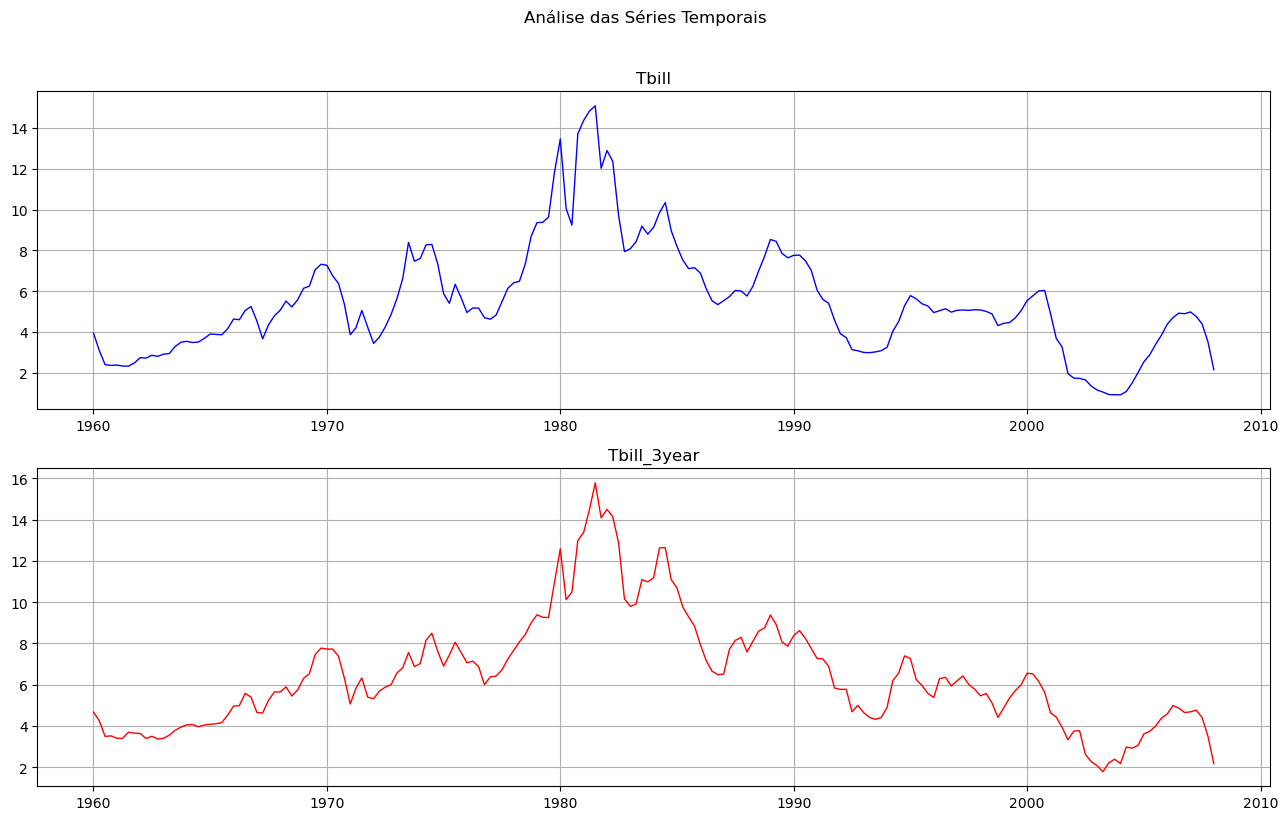

In [72]:
x_2 = quart['Date']
y_1 = quart['Tbill']
y_2 = quart['Tbill_3year']

# Cria a figura e os subplots (2 linha, 1 colunas)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(13, 8))
fig.suptitle('Análise das Séries Temporais', fontsize=12, y=1.02)

# Gráfico 1 (Tbill)
axes[0].plot(x_2, y_1, marker='', linestyle='-', color='blue', linewidth=1)  # Acesso correto: axes[0]
axes[0].set_title('Tbill')
axes[0].grid(True)

# Gráfico 2 (Tbill_3year)
axes[1].plot(x_2, y_2, marker='', linestyle='-', color='red', linewidth=1)  # Acesso correto: axes[1]
axes[1].set_title('Tbill_3year')
axes[1].grid(True)

# Ajusta layout para evitar sobreposição
plt.tight_layout()
plt.show()

### Metodologia Engle-Granger

##### Testando estacionaridade das variáveis

In [74]:
adf1 = adfuller(quart['Tbill'].dropna(), autolag='AIC')
print(adf1)

adf2 = adfuller(quart['Tbill_3year'].dropna(), autolag='AIC')
print(adf2)

(-1.990136872725897, 0.29091441148437797, 7, 185, {'1%': -3.4662005731940853, '5%': -2.8772932777920364, '10%': -2.575167750182615}, 377.0752726929464)
(-2.0071502637602197, 0.2834467850044198, 3, 189, {'1%': -3.4654311561944873, '5%': -2.8769570530458792, '10%': -2.574988319755886}, 348.9956783013181)


In [76]:
adf1_2 = adfuller(quart['Tbill'].diff().dropna(), autolag='AIC')
print(adf1_2)

adf2_2 = adfuller(quart['Tbill_3year'].diff().dropna(), autolag='AIC')
print(adf2_2)

(-5.944933629340032, 2.2156940152420806e-07, 6, 185, {'1%': -3.4662005731940853, '5%': -2.8772932777920364, '10%': -2.575167750182615}, 377.96836908097373)
(-6.140430583024731, 7.995820648376493e-08, 6, 185, {'1%': -3.4662005731940853, '5%': -2.8772932777920364, '10%': -2.575167750182615}, 348.7170900688236)


#### Relação de Cointegração (Relação de longo prazo das variáveis)

In [78]:
import statsmodels.api as sm

Y = quart['Tbill']           # Tbill3m (variável dependente)
X = quart['Tbill_3year']     # Tbill3y (variável explicativa)
X = sm.add_constant(X)       # adiciona constante β0

modelo = sm.OLS(Y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  Tbill   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     2219.
Date:                Wed, 04 Jun 2025   Prob (F-statistic):          4.34e-107
Time:                        06:53:47   Log-Likelihood:                -222.11
No. Observations:                 193   AIC:                             448.2
Df Residuals:                     191   BIC:                             454.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.6815      0.143     -4.768      

#### Comparação - Replicação Slide 48 

In [80]:
import pandas as pd

# Seus coeficientes estimados
meus_coef = {
    'Variável': ['const', 'Tbill_3year'],
    'Coeficiente': [-0.6815, 0.9582],
}

# Coeficientes do slide 48 (exemplo, substitua pelos valores corretos)
slide48_coef = {
    'Variável': ['const', 'Tbill_3year'],
    'Coeficiente': [-0.6814, 0.9581],
}

# Cria DataFrames
df_meus = pd.DataFrame(meus_coef)
df_slide48 = pd.DataFrame(slide48_coef)

# Adiciona coluna para identificar a origem
df_meus['Modelo'] = 'Minha Regressão'
df_slide48['Modelo'] = 'Slide 48 - Aula'

# Reorganiza colunas
df_meus = df_meus[['Modelo', 'Variável', 'Coeficiente']]
df_slide48 = df_slide48[['Modelo', 'Variável', 'Coeficiente']]

# Concatena os dois dataframes
df = pd.concat([df_meus, df_slide48], ignore_index=True)

print(df)

            Modelo     Variável  Coeficiente
0  Minha Regressão        const      -0.6815
1  Minha Regressão  Tbill_3year       0.9582
2  Slide 48 - Aula        const      -0.6814
3  Slide 48 - Aula  Tbill_3year       0.9581


##### Verificar se os resíduos são estacionários

In [82]:
residuos = modelo.resid

from statsmodels.tsa.stattools import adfuller

adf_res = adfuller(residuos, autolag='AIC')
print(f'Estatística ADF: {adf_res[0]}')
print(f'p-valor: {adf_res[1]}')
print('Critérios críticos:')
for key, value in adf_res[4].items():
    print(f'  {key}: {value}')

Estatística ADF: -4.253637564143543
p-valor: 0.000533900879137374
Critérios críticos:
  1%: -3.466598080268425
  5%: -2.8774669520682674
  10%: -2.5752604356654425


##### Teste de cointegração de Engle-Granger

In [84]:
from statsmodels.tsa.stattools import coint

# Eliminar valores ausentes
df = quart[['Tbill', 'Tbill_3year']].dropna()

# Aplicar o teste de Engle-Granger
score, pvalue, crit_values = coint(df['Tbill'], df['Tbill_3year'])

# Exibir resultados
print(f'Estatística de teste: {score}')
print(f'p-valor: {pvalue}')
print('Valores críticos:')
for level, value in zip(['1%', '5%', '10%'], crit_values):
    print(f'  {level}: {value}')

Estatística de teste: -4.2700904909975845
p-valor: 0.0028493470017154385
Valores críticos:
  1%: -3.9543906239149305
  5%: -3.368138523220486
  10%: -3.0666133680555556


##### Escolhendo a ordem do VEC

In [86]:
df = quart[['Tbill', 'Tbill_3year']].dropna()

from statsmodels.tsa.api import VAR

model_var = VAR(df)
lag_order_results = model_var.select_order(maxlags=10)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        1.527       1.562       4.603       1.541
1       -2.490      -2.385     0.08290      -2.447
2       -2.585     -2.409*     0.07541      -2.514
3       -2.595      -2.349     0.07465      -2.495
4       -2.662      -2.346     0.06982      -2.534
5       -2.633      -2.248     0.07185      -2.477
6       -2.763      -2.307     0.06312      -2.578
7       -2.796      -2.270     0.06110     -2.583*
8       -2.791      -2.195     0.06140      -2.550
9      -2.835*      -2.168    0.05883*      -2.564
10      -2.820      -2.084     0.05972      -2.522
--------------------------------------------------


#### VEC Model

In [88]:
import pandas as pd
import statsmodels.api as sm

# Supondo que 'quart' é seu DataFrame original com as variáveis em nível
df = quart[['Tbill', 'Tbill_3year']].dropna()

# === ETAPA 1: Estimar relação de longo prazo ===
y_nivel = df['Tbill']
X_nivel = sm.add_constant(df['Tbill_3year'])
modelo_lr = sm.OLS(y_nivel, X_nivel).fit()
residuos = modelo_lr.resid  # resíduos da relação de cointegração (ECT)

# === ETAPA 2: Construir DataFrame com diferenças e defasagens ===
df_diff = df.diff().dropna()
df_diff['ec_lagged'] = residuos.shift(1)

# Adicionar 8 defasagens das diferenças
for i in range(1, 9):
    df_diff[f'd_Tbill_lag{i}'] = df_diff['Tbill'].shift(i)
    df_diff[f'd_Tbill_3year_lag{i}'] = df_diff['Tbill_3year'].shift(i)

# Eliminar linhas com NA causadas pelas defasagens
df_ecm = df_diff.dropna()

# === ETAPA 3: Estimar modelo ECM ===
# Variável dependente: ∆Tbill (diferença de y)
y_ecm = df_ecm['Tbill']

# Regressoras: ∆Tbill_3year defasada + termo de correção de erro + ∆Tbill defasada + ∆Tbill_3year defasada
regressoras = ['Tbill_3year', 'ec_lagged'] + \
              [f'd_Tbill_lag{i}' for i in range(1, 9)] + \
              [f'd_Tbill_3year_lag{i}' for i in range(1, 9)]

X_ecm = sm.add_constant(df_ecm[regressoras])
modelo_ecm = sm.OLS(y_ecm, X_ecm).fit()

# Resultado
print(modelo_ecm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Tbill   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     37.24
Date:                Wed, 04 Jun 2025   Prob (F-statistic):           1.11e-48
Time:                        06:54:08   Log-Likelihood:                -65.603
No. Observations:                 184   AIC:                             169.2
Df Residuals:                     165   BIC:                             230.3
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0003      0

In [90]:
import pandas as pd
import statsmodels.api as sm

df = quart[['Tbill', 'Tbill_3year']].dropna()

# ETAPA 1: Estimar relação de longo prazo 
y_nivel = df['Tbill']
X_nivel = sm.add_constant(df['Tbill_3year'])
modelo_lr = sm.OLS(y_nivel, X_nivel).fit()
residuos = modelo_lr.resid  # resíduos da relação de cointegração (ECT)

# ETAPA 2: Construir DataFrame com diferenças e defasagens
df_diff = df.diff().dropna()
df_diff['ec_lagged'] = residuos.shift(1)

# Adicionar 8 defasagens das diferenças
for i in range(1, 9):
    df_diff[f'd_Tbill_lag{i}'] = df_diff['Tbill'].shift(i)
    df_diff[f'd_Tbill_3year_lag{i}'] = df_diff['Tbill_3year'].shift(i)

# Eliminar linhas com NA causadas pelas defasagens
df_ecm = df_diff.dropna()

# === ETAPA 3: Estimar modelo ECM SEM constante e SEM Tbill_3year em nível ===
y_ecm = df_ecm['Tbill']

regressoras = ['ec_lagged'] + \
              [f'd_Tbill_lag{i}' for i in range(1, 9)] + \
              [f'd_Tbill_3year_lag{i}' for i in range(1, 9)]

X_ecm = df_ecm[regressoras]  # sem constante
modelo_ecm = sm.OLS(y_ecm, X_ecm).fit()

# Resultado
print(modelo_ecm.summary())

                                 OLS Regression Results                                
Dep. Variable:                  Tbill   R-squared (uncentered):                   0.327
Model:                            OLS   Adj. R-squared (uncentered):              0.258
Method:                 Least Squares   F-statistic:                              4.764
Date:                Wed, 04 Jun 2025   Prob (F-statistic):                    3.37e-08
Time:                        06:54:12   Log-Likelihood:                         -178.43
No. Observations:                 184   AIC:                                      390.9
Df Residuals:                     167   BIC:                                      445.5
Df Model:                          17                                                  
Covariance Type:            nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

#### Comparação - Replicação Slide 50

In [92]:
import pandas as pd

# Coeficientes estimados
dados = {
    "Variável": [
        "ec_lagged / EC1{1}", "d_Tbill_lag1 / D_TBill 3-month{1}", "d_Tbill_lag2 / D_TBill 3-month{2}", "d_Tbill_lag3 / D_TBill 3-month{3}", "d_Tbill_lag4 / D_TBill 3-month{4}",
        "d_Tbill_lag5 / D_TBill 3-month{5}", "d_Tbill_lag6 / D_TBill 3-month{6}", "d_Tbill_lag7 / D_TBill 3-month{7}", "d_Tbill_lag8 / D_TBill 3-month{8}",
        "d_Tbill_3year_lag1 / D_TBill 3-year{1}", "d_Tbill_3year_lag2 / D_TBill 3-year{2}", "d_Tbill_3year_lag3 / D_TBill 3-year{3}", "d_Tbill_3year_lag4 / D_TBill 3-year{4}",
        "d_Tbill_3year_lag5 / D_TBill 3-year{5}", "d_Tbill_3year_lag6 / D_TBill 3-year{6}", "d_Tbill_3year_lag7 / D_TBill 3-year{7}", "d_Tbill_3year_lag8 / D_TBill 3-year{8}"
    ],
    "Coef Estimado": [
        -0.2121, 0.4234, -0.0758, 0.3753, 0.0125,
        0.3925, -0.0673, -0.1128, 0.0668,
        0.0658, -0.3150, 0.0045, -0.0603,
        -0.3177, 0.1087, -0.1543, 0.0939
    ],
    "Coef Slide51": [  # iguais conforme sua instrução
        0.2121, 0.4234, -0.0758, 0.3753, 0.0125,
        0.3925, -0.0673, -0.1128, 0.0668,
        0.0658, -0.3150, 0.0045, -0.0603,
        -0.3177, 0.1087, -0.1543, 0.0939
    ]
}

tabela = pd.DataFrame(dados)
print(tabela)

                                  Variável  Coef Estimado  Coef Slide51
0                       ec_lagged / EC1{1}        -0.2121        0.2121
1        d_Tbill_lag1 / D_TBill 3-month{1}         0.4234        0.4234
2        d_Tbill_lag2 / D_TBill 3-month{2}        -0.0758       -0.0758
3        d_Tbill_lag3 / D_TBill 3-month{3}         0.3753        0.3753
4        d_Tbill_lag4 / D_TBill 3-month{4}         0.0125        0.0125
5        d_Tbill_lag5 / D_TBill 3-month{5}         0.3925        0.3925
6        d_Tbill_lag6 / D_TBill 3-month{6}        -0.0673       -0.0673
7        d_Tbill_lag7 / D_TBill 3-month{7}        -0.1128       -0.1128
8        d_Tbill_lag8 / D_TBill 3-month{8}         0.0668        0.0668
9   d_Tbill_3year_lag1 / D_TBill 3-year{1}         0.0658        0.0658
10  d_Tbill_3year_lag2 / D_TBill 3-year{2}        -0.3150       -0.3150
11  d_Tbill_3year_lag3 / D_TBill 3-year{3}         0.0045        0.0045
12  d_Tbill_3year_lag4 / D_TBill 3-year{4}        -0.0603       

### Metodologia de Johansen

In [94]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Eliminar valores faltantes
df1 = quart[['Tbill', 'Tbill_3year']].dropna()

In [96]:
# Verificando o número de defasagens

from statsmodels.tsa.api import VAR

# Ajuste do VAR com os dados em nível
modelo_var2 = VAR(df1)
res_var2 = modelo_var2.select_order()  
print(res_var2.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        1.538       1.574       4.656       1.553
1       -2.446      -2.339     0.08665      -2.403
2       -2.540     -2.362*     0.07887      -2.468
3       -2.550      -2.300     0.07812      -2.449
4       -2.616      -2.296     0.07310      -2.486
5       -2.587      -2.195     0.07529      -2.428
6       -2.716      -2.253     0.06618      -2.528
7       -2.747      -2.213     0.06417     -2.530*
8       -2.741      -2.136     0.06456      -2.496
9      -2.784*      -2.108    0.06187*      -2.510
10      -2.771      -2.023     0.06275      -2.468
11      -2.781      -1.961     0.06218      -2.448
12      -2.775      -1.884     0.06261      -2.414
13      -2.774      -1.813     0.06269      -2.384
14      -2.743      -1.710     0.06475      -2.324
--------------------------------------------------


#### Teste de cointegração de Johansen

In [98]:
# k_ar_diff: número de lags nas diferenças (Δ)

johansen_result = coint_johansen(df1, det_order=1, k_ar_diff=8)       

# det_order=0 (sem constante), 1 (com)
# k_ar_diff: número de defasagens usado no modelo VAR em diferenças

print("Estatísticas de traço:")
print(johansen_result.lr1)  # Estatísticas de traço
print("\nValores críticos (90%, 95%, 99%):")
print(johansen_result.cvt)  # Valores críticos

# Interpretação:
# Se lr1 > valor crítico, rejeita H0 (há cointegração)

Estatísticas de traço:
[34.25858151  2.07339639]

Valores críticos (90%, 95%, 99%):
[[16.1619 18.3985 23.1485]
 [ 2.7055  3.8415  6.6349]]


In [100]:
import pandas as pd

# Estatísticas de traço e valores críticos
estatisticas_traco = [34.2586, 2.0734]
valores_criticos_95 = [18.3985, 3.8415]
hipoteses = ['r = 0', 'r ≤ 1']

# Verificação se rejeita H0 ao nível de 5%
rejeita_h0 = [stat > crit for stat, crit in zip(estatisticas_traco, valores_criticos_95)]

# Criar DataFrame
tabela_johansen = pd.DataFrame({
    'Hipótese nula (H0)': hipoteses,
    'Estatística de Traço': estatisticas_traco,
    'Valor Crítico (5%)': valores_criticos_95,
    'Rejeita H0 (5%)?': ['Sim' if r else 'Não' for r in rejeita_h0]
})

print(tabela_johansen)


  Hipótese nula (H0)  Estatística de Traço  Valor Crítico (5%)  \
0              r = 0               34.2586             18.3985   
1              r ≤ 1                2.0734              3.8415   

  Rejeita H0 (5%)?  
0              Sim  
1              Não  


#### VEC Model

In [102]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Escolha o número de lags (k_ar_diff) e o rank (r) com base no teste de Johansen
k_ar_diff = 9  
coint_rank = 1   # baseado no teste de Johansen

vecm = VECM(df1, k_ar_diff=k_ar_diff, coint_rank=coint_rank, deterministic='n')
vecm_fit = vecm.fit()

print(vecm_fit.summary())  # Aqui aparece a matriz α (ajuste) e β (cointegração)

Det. terms outside the coint. relation & lagged endog. parameters for equation Tbill
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
L1.Tbill           0.4269      0.135      3.159      0.002       0.162       0.692
L1.Tbill_3year     0.0999      0.144      0.693      0.488      -0.183       0.382
L2.Tbill          -0.0366      0.144     -0.255      0.799      -0.318       0.245
L2.Tbill_3year    -0.3310      0.144     -2.295      0.022      -0.614      -0.048
L3.Tbill           0.4534      0.135      3.347      0.001       0.188       0.719
L3.Tbill_3year    -0.0608      0.144     -0.421      0.674      -0.344       0.222
L4.Tbill           0.0351      0.131      0.267      0.790      -0.223       0.293
L4.Tbill_3year    -0.1096      0.136     -0.805      0.421      -0.376       0.157
L5.Tbill           0.4437      0.132      3.372      0.001       0.186       0.701
L5

#### Comparação - Replicação Slide 50

In [104]:
import pandas as pd

# Dados do VAR
var_names = [
    "L1.Tbill", "L1.Tbill_3year", "L2.Tbill", "L2.Tbill_3year", "L3.Tbill", "L3.Tbill_3year",
    "L4.Tbill", "L4.Tbill_3year", "L5.Tbill", "L5.Tbill_3year", "L6.Tbill", "L6.Tbill_3year",
    "L7.Tbill", "L7.Tbill_3year", "L8.Tbill", "L8.Tbill_3year", "L9.Tbill", "L9.Tbill_3year"
]
var_coefs = [
    0.4269, 0.0999, -0.0366, -0.3310, 0.4534, -0.0608, 0.0351, -0.1096, 0.4437, -0.3401,
    -0.0584, 0.1275, -0.0640, -0.1840, 0.0585, 0.1366, 0.2292, -0.2708
]

# Dados do ECM
ecm_names = [
    "d_Tbill_lag1", "d_Tbill_lag2", "d_Tbill_lag3", "d_Tbill_lag4", "d_Tbill_lag5",
    "d_Tbill_lag6", "d_Tbill_lag7", "d_Tbill_lag8", "d_Tbill_3year_lag1", "d_Tbill_3year_lag2",
    "d_Tbill_3year_lag3", "d_Tbill_3year_lag4", "d_Tbill_3year_lag5", "d_Tbill_3year_lag6",
    "d_Tbill_3year_lag7", "d_Tbill_3year_lag8", "ec_lagged"
]
ecm_coefs = [
    0.4234, -0.0758, 0.3753, 0.0125, 0.3925, -0.0673, -0.1128, 0.0668,
    0.0658, -0.3150, 0.0045, -0.0603, -0.3177, 0.1087, -0.1543, 0.0939, -0.2121
]

# Criar DataFrame combinado com preenchimento de NaN para tamanhos diferentes
max_len = max(len(var_names), len(ecm_names))
var_names += [None] * (max_len - len(var_names))
var_coefs += [None] * (max_len - len(var_coefs))
ecm_names += [None] * (max_len - len(ecm_names))
ecm_coefs += [None] * (max_len - len(ecm_coefs))

# Construir a tabela
tabela = pd.DataFrame({
    "Meu Modelo (VEC)": var_names,
    "Coef": var_coefs,
    "Slide 50 - VEC": ecm_names,
    "Coef ": ecm_coefs
})

# Exibir
print(tabela.to_string(index=False))


Meu Modelo (VEC)    Coef     Slide 50 - VEC   Coef 
        L1.Tbill  0.4269       d_Tbill_lag1  0.4234
  L1.Tbill_3year  0.0999       d_Tbill_lag2 -0.0758
        L2.Tbill -0.0366       d_Tbill_lag3  0.3753
  L2.Tbill_3year -0.3310       d_Tbill_lag4  0.0125
        L3.Tbill  0.4534       d_Tbill_lag5  0.3925
  L3.Tbill_3year -0.0608       d_Tbill_lag6 -0.0673
        L4.Tbill  0.0351       d_Tbill_lag7 -0.1128
  L4.Tbill_3year -0.1096       d_Tbill_lag8  0.0668
        L5.Tbill  0.4437 d_Tbill_3year_lag1  0.0658
  L5.Tbill_3year -0.3401 d_Tbill_3year_lag2 -0.3150
        L6.Tbill -0.0584 d_Tbill_3year_lag3  0.0045
  L6.Tbill_3year  0.1275 d_Tbill_3year_lag4 -0.0603
        L7.Tbill -0.0640 d_Tbill_3year_lag5 -0.3177
  L7.Tbill_3year -0.1840 d_Tbill_3year_lag6  0.1087
        L8.Tbill  0.0585 d_Tbill_3year_lag7 -0.1543
  L8.Tbill_3year  0.1366 d_Tbill_3year_lag8  0.0939
        L9.Tbill  0.2292          ec_lagged -0.2121
  L9.Tbill_3year -0.2708               None     NaN


I didn't any package to run the SVEC in python. So, i will save this dataframe in excel and make this last exercise in R, where apparently has a specific package

In [221]:
# df1.to_excel('df1_vecm.xlsx')

Note: you may need to restart the kernel to use updated packages.Collecting pypandoc



In [7]:
#import pypandoc
#pypandoc.get_pandoc_version()  # Verifica se está tudo certo

'3.7.0.2'